<!-- SPDX-License-Identifier: Apache-2.0 -->
<!-- Copyright (c) 2025 FlyDSL Project Contributors -->

# MFMA register layouts

`06_make_tile` drew how a tile is *partitioned*; this one draws how an **MFMA instruction**
lays its A, B, C operands across the 64 lanes of a wavefront — the "which lane holds which
element" map that `lesson_01` / `lesson_04` rely on.

The layouts are **not simulated**: `fx.make_mma_atom(fx.rocdl.MFMA(M, N, K, ty))` builds the
real atom, and `fx.utils.print_typst(atom)` reads its own `tv_layout_a/b/c` and draws the
A (M×K), B (K×N), C (M×N) grids — each cell labelled `T{lane} / V{value}` and coloured by
lane. So every picture below is the DSL's ground truth for that instruction.

In [1]:
import os
import tempfile

os.environ["FLYDSL_RUNTIME_ENABLE_CACHE"] = "0"

import torch  # noqa: F401  (parity with the sibling notebooks)
from IPython.display import SVG, Code, display

import flydsl.compiler as flyc
import flydsl.expr as fx

try:
    import typst  # `pip install typst`
except ImportError:
    typst = None

_TYP_DIR = tempfile.mkdtemp()


def render_typst(name):
    """Show a Typst file written by print_typst: inline SVG when `typst` is available,
    else the raw Typst source."""
    path = os.path.join(_TYP_DIR, name)
    if typst is None:
        with open(path) as f:
            display(Code(f.read(), language="typst"))
        return
    out = typst.compile(path, format="svg")
    if isinstance(out, list):
        out = out[0]
    if isinstance(out, (bytes, bytearray)):
        out = out.decode()
    display(SVG(out))


def dump(name, m, n, k, ty):
    """Build the real MFMA atom from FlyDSL, print its TV layouts, and draw A/B/C.

    Everything comes from the atom itself: `layout_{A,B,C}_tv` are what the hardware
    instruction defines; print_typst renders those, it does not re-derive them."""
    atom = fx.make_mma_atom(fx.rocdl.MFMA(m, n, k, ty))
    print(f"{name}:  shape_mnk = {atom.shape_mnk}")
    print(f"    A_tv = {atom.layout_A_tv}")
    print(f"    B_tv = {atom.layout_B_tv}")
    print(f"    C_tv = {atom.layout_C_tv}")
    p = os.path.join(_TYP_DIR, name + ".typ")
    if os.path.exists(p):
        os.remove(p)
    fx.utils.print_typst(atom, file=p)

## The logic (so the pictures aren't random)

A wavefront is **64 lanes**, and every operand tile is spread across them:

$$\text{registers per lane} = \frac{\text{tile elements}}{64}$$

So for the three instructions below:

| instruction | A = M·K | C = M·N | A regs/lane | C regs/lane |
|---|---|---|---|---|
| `16×16×4`  | 64   | 256  | 1  | 4  |
| `16×16×16` | 256  | 256  | 4  | 4  |
| `32×32×8`  | 256  | 1024 | 4  | **16** |

Two roles to read off the grids:

* **A / B** — the *free* dim (M for A, N for B) goes on **lanes**; the *contraction* K is split
  into `(lane-groups) × (a contiguous per-lane vector)`. Each lane feeds a contiguous chunk of K.
* **C** — a lane holds a contiguous run along **M** for a fixed **N**.

The catch: **A/B layout ≠ C layout** (inputs index the contraction per lane, the output indexes
rows). That mismatch is the transpose you pay when feeding one GEMM's C into the next GEMM —
the P-transpose in attention. Watch the `T#/V#` labels move between the A and C grids to see it.

In [2]:
@flyc.jit
def emit():
    dump("mfma_16x16x16_bf16", 16, 16, 16, fx.BFloat16)
    dump("mfma_16x16x4_f32", 16, 16, 4, fx.Float32)
    dump("mfma_32x32x8_f32", 32, 32, 8, fx.Float32)
    dump("mfma_32x32x8_f16", 32, 32, 8, fx.Float16)


emit()

mfma_16x16x16_bf16:  shape_mnk = IntTuple<(16,16,16)>
    A_tv = Layout<((16,4),4):((1,64),16)>
    B_tv = Layout<((16,4),4):((1,64),16)>
    C_tv = Layout<((16,4),(4,1)):((16,4),(1,16))>
mfma_16x16x4_f32:  shape_mnk = IntTuple<(16,16,4)>
    A_tv = Layout<((16,4),1):((1,16),16)>
    B_tv = Layout<((16,4),1):((1,16),16)>
    C_tv = Layout<((16,4),(4,1)):((16,4),(1,16))>
mfma_32x32x8_f32:  shape_mnk = IntTuple<(32,32,8)>
    A_tv = Layout<((32,2),4):((1,128),32)>
    B_tv = Layout<((32,2),4):((1,128),32)>
    C_tv = Layout<((32,2),(4,4)):((32,4),(1,8))>


mfma_32x32x8_f16:  shape_mnk = IntTuple<(32,32,8)>
    A_tv = Layout<((32,2),4):((1,128),32)>
    B_tv = Layout<((32,2),4):((1,128),32)>
    C_tv = Layout<((32,2),(4,4)):((32,4),(1,8))>


## `MFMA(16, 16, 16, bf16)` — the Lesson 04 instruction

`A_tv = ((16,4),4)`, `C_tv = ((16,4),(4,1))`: 64 threads, **4 values each** for A, B, and C.
In the **C** grid a lane owns 4 rows (kv) of one column (q): lanes 0/16/32/48 tile the 16 rows
of column 0 in blocks of 4 — that is exactly the `k_outer` split the softmax reduces over. In
the **A** grid the same lane instead owns 4 contiguous K (head-dim) of one row.

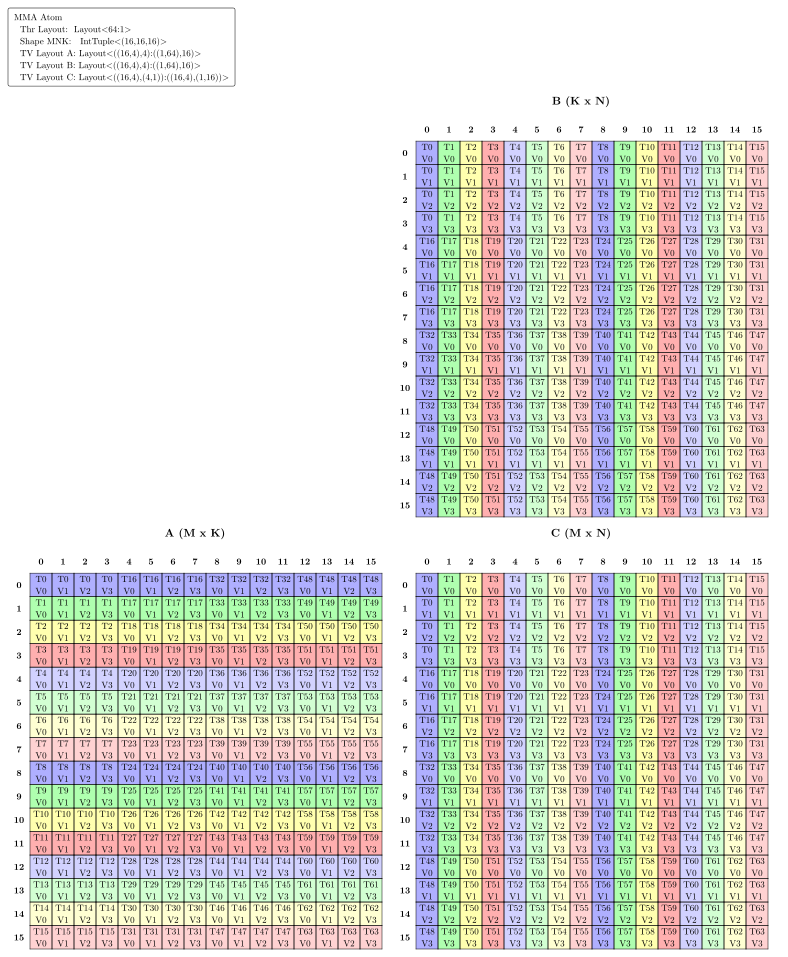

In [3]:
render_typst("mfma_16x16x16_bf16.typ")

## The same map, by hand (no FlyDSL)

The diagram above is `print_typst` reading the atom. Here is the identical `16×16×16` layout
from the textbook formulas — pure Python, no layout algebra — so you can check they agree.
With `lane = k_outer*16 + mn` (`k_outer = lane//16` ∈ 0..3, `mn = lane%16` ∈ 0..15, `e` = the
value index 0..3):

- **C** (output `S[kv, q]`): `kv = k_outer*4 + e`, `q = mn` → `lane = (kv//4)*16 + q`, `e = kv%4`
- **A** (input `K[kv, hd]`): `kv = mn`, `hd = k_outer*4 + e` → `lane = (hd//4)*16 + kv`, `e = hd%4`

Each cell below prints `T{lane}/V{e}`; compare to the coloured C and A grids above — the same
lane sits in every cell. This is exactly what `make_tiled_mma` derives for you.

In [4]:
# MFMA 16x16x16 lane<->element map, derived BY HAND (pure Python, no FlyDSL).
def lane_C(kv, q):
    return (kv // 4) * 16 + q, kv % 4   # -> (lane, value e)  for output S[kv, q]


def lane_A(kv, hd):
    return (hd // 4) * 16 + kv, hd % 4  # -> (lane, value e)  for input  K[kv, hd]


print("C fragment  S[kv, q]  ->  T{lane}/V{e}    (rows = kv, cols = q)")
for kv in range(16):
    print("  " + " ".join(f"T{(c := lane_C(kv, q))[0]:02d}V{c[1]}" for q in range(16)))

print("\nA fragment  K[kv, hd] ->  T{lane}/V{e}    (rows = kv, cols = hd)")
for kv in range(16):
    print("  " + " ".join(f"T{(c := lane_A(kv, hd))[0]:02d}V{c[1]}" for hd in range(16)))

# Cross-check: query column q=0 of C lives in lanes 0/16/32/48 (the k_outer split the softmax reduces)
print("\nq=0 column of C -> (lane, e) per kv:", [lane_C(kv, 0) for kv in range(16)])

C fragment  S[kv, q]  ->  T{lane}/V{e}    (rows = kv, cols = q)
  T00V0 T01V0 T02V0 T03V0 T04V0 T05V0 T06V0 T07V0 T08V0 T09V0 T10V0 T11V0 T12V0 T13V0 T14V0 T15V0
  T00V1 T01V1 T02V1 T03V1 T04V1 T05V1 T06V1 T07V1 T08V1 T09V1 T10V1 T11V1 T12V1 T13V1 T14V1 T15V1
  T00V2 T01V2 T02V2 T03V2 T04V2 T05V2 T06V2 T07V2 T08V2 T09V2 T10V2 T11V2 T12V2 T13V2 T14V2 T15V2
  T00V3 T01V3 T02V3 T03V3 T04V3 T05V3 T06V3 T07V3 T08V3 T09V3 T10V3 T11V3 T12V3 T13V3 T14V3 T15V3
  T16V0 T17V0 T18V0 T19V0 T20V0 T21V0 T22V0 T23V0 T24V0 T25V0 T26V0 T27V0 T28V0 T29V0 T30V0 T31V0
  T16V1 T17V1 T18V1 T19V1 T20V1 T21V1 T22V1 T23V1 T24V1 T25V1 T26V1 T27V1 T28V1 T29V1 T30V1 T31V1
  T16V2 T17V2 T18V2 T19V2 T20V2 T21V2 T22V2 T23V2 T24V2 T25V2 T26V2 T27V2 T28V2 T29V2 T30V2 T31V2
  T16V3 T17V3 T18V3 T19V3 T20V3 T21V3 T22V3 T23V3 T24V3 T25V3 T26V3 T27V3 T28V3 T29V3 T30V3 T31V3
  T32V0 T33V0 T34V0 T35V0 T36V0 T37V0 T38V0 T39V0 T40V0 T41V0 T42V0 T43V0 T44V0 T45V0 T46V0 T47V0
  T32V1 T33V1 T34V1 T35V1 T36V1 T37V1 T38V1 T39V1 T40V

## `MFMA(16, 16, 4, f32)` — small K

`A_tv = ((16,4),1)`: with K=4, the A tile is only 16·4 = 64 = one element per lane, so each
lane holds a **single** A value (`V0` only). The **C** grid is unchanged from the 16×16×16 case
(`C_tv = ((16,4),(4,1))`, 4 values/lane) because the output is still 16×16 — C depends on M·N,
not K. Compare the A grids of this and the previous instruction: same 16×16 thread arrangement,
but 1 value/lane instead of 4.

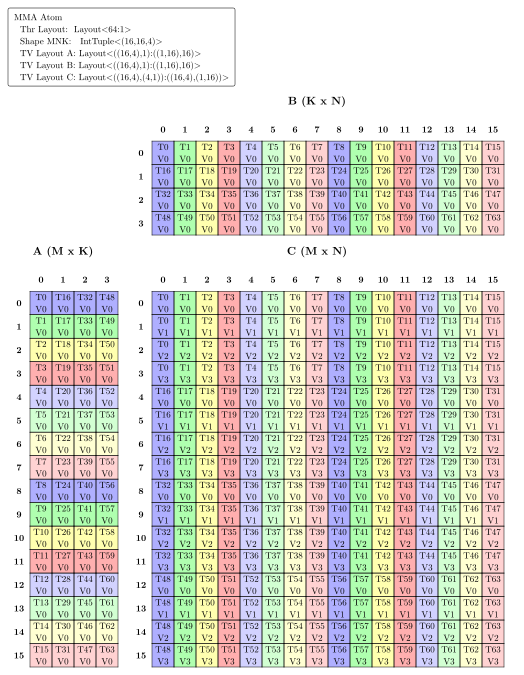

In [5]:
render_typst("mfma_16x16x4_f32.typ")

## `MFMA(32, 32, 8, f32)` — big output, 16 C values/lane

`C_tv = ((32,2),(4,4))`: the output is 32·32 = 1024 / 64 = **16 values per lane**, and the 32
rows are split across only **2** lane-groups (`lane//32`) instead of 4. That is why a
`32×32`-based softmax needs just **one** `shuffle_xor(32)` to merge the row-groups, versus the
two shuffles the 16×16 kernel uses. A/B stay at 4 values/lane (`A = 32·8 = 256 / 64 = 4`).

In [6]:
render_typst("mfma_32x32x8_f32.typ")

## `MFMA(32, 32, 8, f16)` — same layout, fp16 inputs (your file 02)

This is the `mfma_f32_32x32x8` fp16 instruction. Its layouts are **identical** to the f32
`32×32×8` above — `C_tv = ((32,2),(4,4))`, `A_tv = ((32,2),4)` — because the TV layout depends
on the shape `M×N×K` and the 64-lane grid, **not** on the input dtype. So the non-trivial
second value dimension (4 along N → 16 C values/lane) is a property of the `32×32` output
shape, not of fp16 vs fp32.

In [7]:
render_typst("mfma_32x32x8_f16.typ")

## How to read these, and where they come from

Each diagram is `print_typst(atom)` — it pulls `atom.layout_A_tv`, `layout_B_tv`,
`layout_C_tv` (the hardware TV layouts FlyDSL stores) and draws them; no lane math is
re-implemented here. To try another instruction, just add a `dump(...)` line with a shape from
the `mfma-operand-layout` catalog (e.g. FP8 `MFMA(16,16,32, Float8E4M3FNUZ)`).

The recurring reading:
- **`tile / 64`** sets values-per-lane (grows with M·N for C, with K for A/B).
- **A/B**: free dim on lanes, K contiguous per lane; **C**: M-run per lane for a fixed N.
- **A/B layout ≠ C layout** → the transpose when chaining GEMMs.

In a full kernel you rarely stare at these: `make_tiled_mma` + `make_tiled_copy_{A,B,C}` consume
exactly these TV layouts so your copies land data in the lanes the MFMA expects. This notebook
just makes the otherwise-invisible mapping visible.

---
*Companion: `learn_fmha/lesson_01_single_mfma.py` (verify-don't-trust), `lesson_04_dimensions.md`
(the 16×16×16 lane tables), and `06_make_tile.ipynb` (tiling).*